In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [47]:
import kagglehub
kagglehub.login()
path = kagglehub.competition_download('store-sales-time-series-forecasting')

In [48]:
print(path)
path = Path(path)

/root/.cache/kagglehub/competitions/store-sales-time-series-forecasting


In [49]:
train =  pd.read_csv(path / 'train.csv', parse_dates=['date'])
test = pd.read_csv(path/'test.csv', parse_dates=['date'])
stores = pd.read_csv(path/'stores.csv')
holidays = pd.read_csv(path/'holidays_events.csv', parse_dates=['date'])
oil = pd.read_csv(path/'oil.csv', parse_dates=['date'])
transactions = pd.read_csv(path/'transactions.csv', parse_dates=['date'])

In [50]:
print(f"train:{train.shape}")
print(f"test:{test.shape}")
print(f"stores:{stores.shape}")
print(f"holidays:{holidays.shape}")
print(f"oil:{oil.shape}")
print(f"transactions:{transactions.shape}")

train:(3000888, 6)
test:(28512, 5)
stores:(54, 5)
holidays:(350, 6)
oil:(1218, 2)
transactions:(83488, 3)


In [51]:
def inspect_df(df:pd.DataFrame, name:str) -> None:
  print(f"{name}")
  print(f"shape:{df.shape}")
  print(f"Período: {df.select_dtypes('datetime64').min().values} "
        f"→ {df.select_dtypes('datetime64').max().values}"
        if not df.select_dtypes('datetime64').empty else "")
  print(f"\nColumnas y tipos:")
  print(df.dtypes)
  print(f"\nNulos:")
  nulls = df.isnull().sum()
  print(nulls[nulls > 0] if nulls.any() else "  Sin nulos")
  print(f"\nPrimeras filas:")
  display(df.head(3))
  print(f"\nUltimas filas:")
  display(df.tail(3))
  print(f"{'='*40}")


In [52]:
inspect_df(train,'train.csv')
inspect_df(test, 'test.csv')
inspect_df(stores, 'stores.csv')
inspect_df(holidays, 'holidays.csv')
inspect_df(oil, 'oil.csv')
inspect_df(transactions, 'transactions.csv')

train.csv
shape:(3000888, 6)
Período: ['2013-01-01T00:00:00.000000000'] → ['2017-08-15T00:00:00.000000000']

Columnas y tipos:
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object

Nulos:
  Sin nulos

Primeras filas:


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0



Ultimas filas:


,id,date,store_nbr,family,sales,onpromotion
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8
3000887,3000887,2017-08-15,9,SEAFOOD,16.000,0


test.csv
shape:(28512, 5)
Período: ['2017-08-16T00:00:00.000000000'] → ['2017-08-31T00:00:00.000000000']

Columnas y tipos:
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
onpromotion             int64
dtype: object

Nulos:
  Sin nulos

Primeras filas:


...

,date,dcoilwtico
1215,2017-08-29,46.46
1216,2017-08-30,45.96
1217,2017-08-31,47.26


transactions.csv
shape:(83488, 3)
Período: ['2013-01-01T00:00:00.000000000'] → ['2017-08-15T00:00:00.000000000']

Columnas y tipos:
date            datetime64[ns]
store_nbr                int64
transactions             int64
dtype: object

Nulos:
  Sin nulos

Primeras filas:


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358



Ultimas filas:


,date,store_nbr,transactions
83485,2017-08-15,52,2255
83486,2017-08-15,53,932
83487,2017-08-15,54,802


In [53]:
print(f"  train:  {train['store_nbr'].nunique()} tiendas únicas")
print(f"  stores: {stores['store_nbr'].nunique()} tiendas únicas")
print(f"  Coinciden: {set(train['store_nbr'].unique()) == set(stores['store_nbr'].unique())}")

  train:  54 tiendas únicas
  stores: 54 tiendas únicas
  Coinciden: True


In [54]:
def process_holidays(holidays: pd.DataFrame,
                     stores: pd.DataFrame) -> pd.DataFrame:
    """
    Procesa holidays considerando el locale correcto
    para cada tienda, evitando duplicados en el merge.
    """

    # Separar por tipo de locale
    national = holidays[holidays['locale'] == 'National'].copy()
    regional = holidays[holidays['locale'] == 'Regional'].copy()
    local    = holidays[holidays['locale'] == 'Local'].copy()

    # Nacional → aplica a todas, solo necesita date
    national_clean = (
        national
        .sort_values('transferred')
        .drop_duplicates(subset=['date'])
        [['date', 'type', 'locale', 'description', 'transferred']]
        .rename(columns={
            'type':        'holiday_type',
            'description': 'holiday_description'
        })
    )

    # Regional → locale_name es el estado (state en stores)
    regional_clean = (
        regional
        .sort_values('transferred')
        .drop_duplicates(subset=['date', 'locale_name'])
        [['date', 'locale_name', 'type', 'description', 'transferred']]
        .rename(columns={
            'type':        'holiday_type',
            'locale_name': 'state',
            'description': 'holiday_description'
        })
    )

    # Local → locale_name es la ciudad (city en stores)
    local_clean = (
        local
        .sort_values('transferred')
        .drop_duplicates(subset=['date', 'locale_name'])
        [['date', 'locale_name', 'type', 'description', 'transferred']]
        .rename(columns={
            'type':        'holiday_type',
            'locale_name': 'city',
            'description': 'holiday_description'
        })
    )

    return national_clean, regional_clean, local_clean


def build_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construye el dataset final mergeando todos los archivos.
    """
    # 1. Merge con stores
    df = df.merge(stores, on='store_nbr', how='left')

    # 2. Merge con oil
    df = df.merge(oil, on='date', how='left')

    # 3. Merge con transactions
    df = df.merge(transactions, on=['date', 'store_nbr'], how='left')

    # 4. Merge con holidays — corregido
    national_h, regional_h, local_h = process_holidays(holidays, stores)

    # Nacional → merge solo por date
    df = df.merge(national_h, on='date', how='left')

    # Regional → merge por date + state
    df = df.merge(
        regional_h,
        on=['date', 'state'],
        how='left',
        suffixes=('', '_regional')
    )

    # Local → merge por date + city
    df = df.merge(
        local_h,
        on=['date', 'city'],
        how='left',
        suffixes=('', '_local')
    )

    # Consolidar holiday_type en una sola columna
    # Prioridad: local > regional > nacional
    df['holiday_type'] = (
        df['holiday_type_local']
        .fillna(df['holiday_type_regional'])
        .fillna(df['holiday_type'])
    )
    df['holiday_description'] = (
        df['holiday_description_local']
        .fillna(df['holiday_description_regional'])
        .fillna(df['holiday_description'])
    )

    # Limpiar columnas intermedias
    cols_to_drop = [c for c in df.columns
                    if '_regional' in c or '_local' in c]
    df = df.drop(columns=cols_to_drop)

    return df


# Reconstruir datasets
train_full = build_dataset(train)
test_full  = build_dataset(test)

# Validar que se eliminaron los duplicados
print("✅ Validación post-corrección:")
duplicados = train_full.duplicated(
    subset=['date', 'store_nbr', 'family']
).sum()
print(f"  Filas duplicadas: {duplicados:,}  ← debe ser 0")
print(f"  Shape:            {train_full.shape}")

✅ Validación post-corrección:
  Filas duplicadas: 0  ← debe ser 0
  Shape:            (3000888, 16)


In [90]:
train_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 22 columns):
 #   Column               Dtype         
---  ------               -----         
 0   id                   int64         
 1   date                 datetime64[ns]
 2   store_nbr            int64         
 3   family               object        
 4   sales                float64       
 5   onpromotion          int64         
 6   city                 object        
 7   state                object        
 8   type                 object        
 9   cluster              int64         
 10  dcoilwtico           float64       
 11  transactions         float64       
 12  holiday_type         object        
 13  locale               object        
 14  holiday_description  object        
 15  transferred          object        
 16  day_of_week          object        
 17  month                int32         
 18  month_name           object        
 19  year                 

In [55]:
train_full.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,transactions,holiday_type,locale,holiday_description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Primer dia del ano,False


In [56]:
print("Validacion post merge")
print(f"\nNulos por columna:")
nulls = train_full.isnull().sum()
nulls_percent = (nulls / len(train_full) * 100).round(2)
null_report = pd.DataFrame({
    'nulos': nulls,
    'porcentaje': nulls_percent
}).query('nulos > 0').sort_values('porcentaje', ascending=False)
print(null_report)

print(f"\nShape final: {train_full.shape}")
print(f"Período:  {train_full['date'].min()} --> {train_full['date'].max()}")
print(f"Tiendas:  {train_full['store_nbr'].nunique()}")
print(f"Familias: {train_full['family'].nunique()}")
print(f"Combinaciones tienda-familia: {train_full.groupby(['store_nbr','family']).ngroups}")

Validacion post merge

Nulos por columna:
                       nulos  porcentaje
transferred          2746062       91.51
locale               2746062       91.51
holiday_type         2733291       91.08
holiday_description  2733291       91.08
dcoilwtico            928422       30.94
transactions          245784        8.19

Shape final: (3000888, 16)
Período:  2013-01-01 00:00:00 --> 2017-08-15 00:00:00
Tiendas:  54
Familias: 33
Combinaciones tienda-familia: 1782


In [57]:
import os
os.makedirs('../data/processed',exist_ok=True)

train_full.to_parquet('../data/processed/train_merged.parquet', index=False)
test_full.to_parquet('../data/processed/test_merged.parquet', index=False)
print("Datasets loaded")

Datasets loaded


In [58]:
print("Estadistica descriptiva")
print(train_full['sales'].describe().round(2))

print(f"\n Adicionales:")
print(f"  Ceros:    {(train_full['sales'] == 0).sum():,} "
      f"({(train_full['sales'] == 0).mean()*100:.1f}%)")
print(f"  Negativos: {(train_full['sales'] < 0).sum():,}")
print(f"  Máximo:    {train_full['sales'].max():,.0f}")
print(f"  Mediana:   {train_full['sales'].median():,.0f}")

Estadistica descriptiva
count    3000888.00
mean         357.78
std         1102.00
min            0.00
25%            0.00
50%           11.00
75%          195.85
max       124717.00
Name: sales, dtype: float64

 Adicionales:
  Ceros:    939,130 (31.3%)
  Negativos: 0
  Máximo:    124,717
  Mediana:   11


In [59]:
os.makedirs('../notebooks/figures',exist_ok=True)

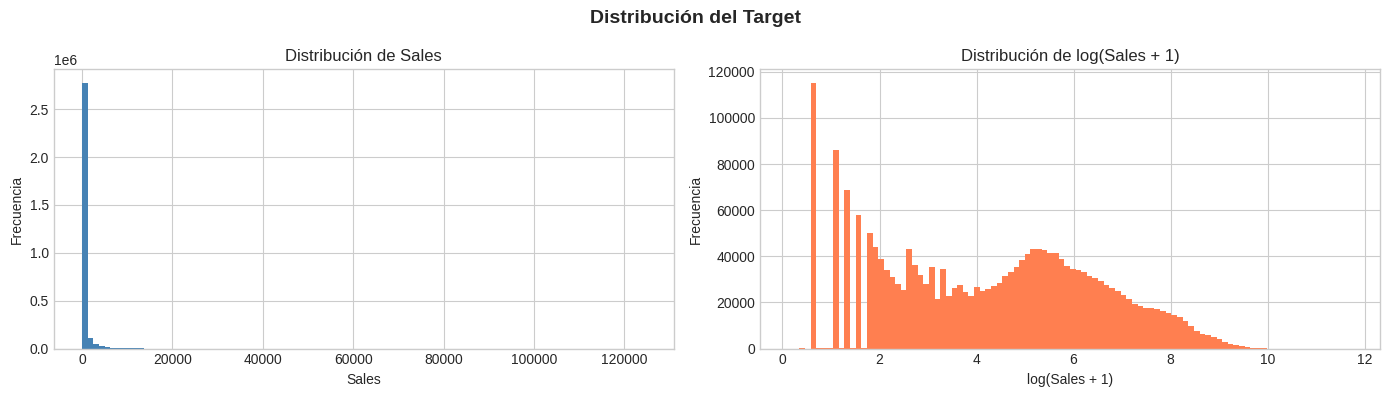

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución original
axes[0].hist(train_full['sales'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Distribución de Sales')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frecuencia')

# Distribución con log transform (excluye ceros)
sales_nonzero = train_full[train_full['sales'] > 0]['sales']
axes[1].hist(np.log1p(sales_nonzero), bins=100, color='coral', edgecolor='none')
axes[1].set_title('Distribución de log(Sales + 1)')
axes[1].set_xlabel('log(Sales + 1)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Distribución del Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/figures/01_sales_distribution.png', dpi=150)
plt.show()

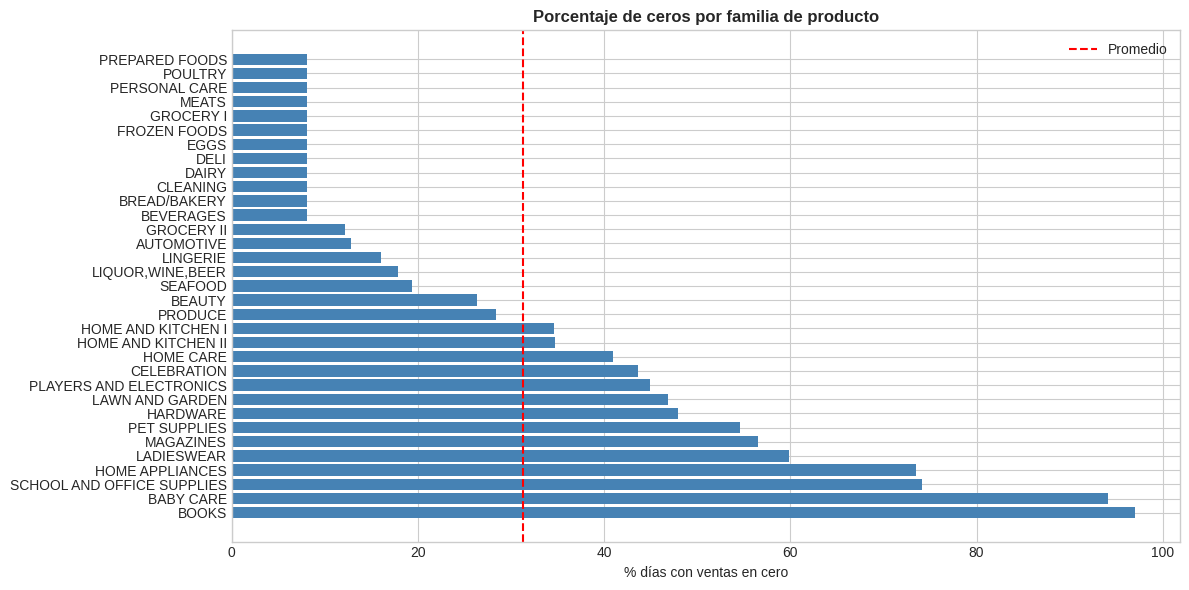

                    family  pct_zeros
                     BOOKS       97.0
                 BABY CARE       94.1
SCHOOL AND OFFICE SUPPLIES       74.1
           HOME APPLIANCES       73.5
                LADIESWEAR       59.8
                 MAGAZINES       56.5
              PET SUPPLIES       54.6
                  HARDWARE       47.9
           LAWN AND GARDEN       46.8
   PLAYERS AND ELECTRONICS       44.9
               CELEBRATION       43.6
                 HOME CARE       40.9
       HOME AND KITCHEN II       34.7
        HOME AND KITCHEN I       34.6
                   PRODUCE       28.4
                    BEAUTY       26.3
                   SEAFOOD       19.4
          LIQUOR,WINE,BEER       17.9
                  LINGERIE       16.0
                AUTOMOTIVE       12.8
                GROCERY II       12.1
                 BEVERAGES        8.1
              BREAD/BAKERY        8.1
                  CLEANING        8.1
                     DAIRY        8.1
            

In [61]:
zeros_by_family = (
    train_full.groupby('family')['sales']
    .apply(lambda x: (x == 0).mean() * 100)
    .round(1)
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'sales': 'pct_zeros'})
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(zeros_by_family['family'],
               zeros_by_family['pct_zeros'],
               color='steelblue')
ax.set_xlabel('% días con ventas en cero')
ax.set_title('Porcentaje de ceros por familia de producto', fontweight='bold')
ax.axvline(x=zeros_by_family['pct_zeros'].mean(),
           color='red', linestyle='--', label='Promedio')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/figures/02_zeros_by_family.png', dpi=150)
plt.show()

print(zeros_by_family.to_string(index=False))

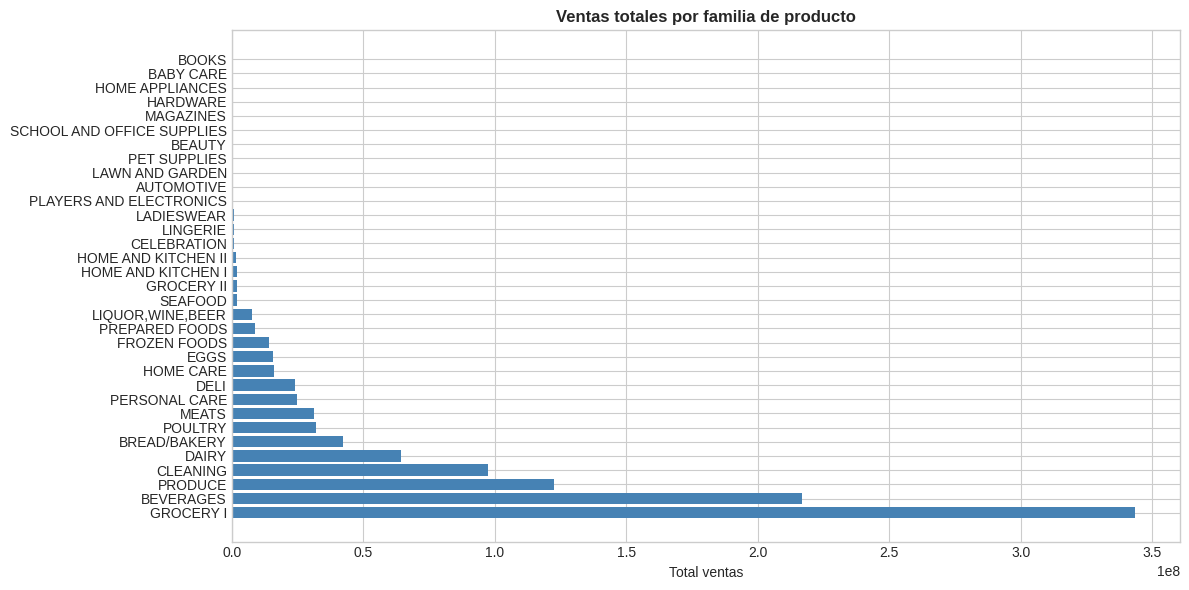

In [62]:
sales_by_family = (
    train_full.groupby('family')['sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(sales_by_family['family'],
        sales_by_family['sales'],
        color='steelblue')
ax.set_xlabel('Total ventas')
ax.set_title('Ventas totales por familia de producto', fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/figures/03_sales_by_family.png', dpi=150)
plt.show()

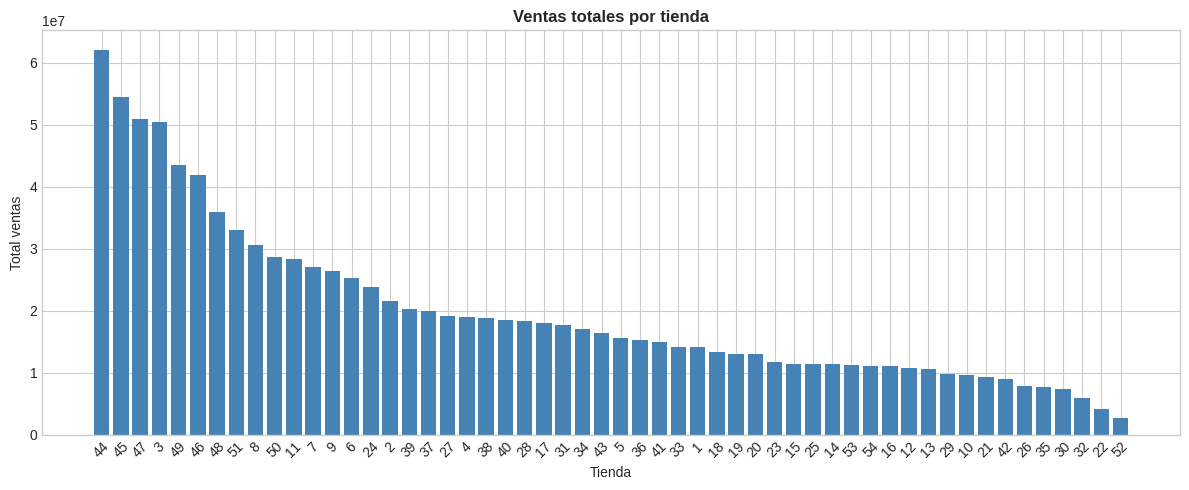


Top 5 tiendas:
   store_nbr         sales
0         44  6.208755e+07
1         45  5.449801e+07
2         47  5.094831e+07
3          3  5.048191e+07
4         49  4.342010e+07

Bottom 5 tiendas:
    store_nbr         sales
49         35  7.676679e+06
50         30  7.382074e+06
51         32  5.951796e+06
52         22  4.090202e+06
53         52  2.696170e+06


In [63]:
sales_by_store = (
    train_full.groupby('store_nbr')['sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(sales_by_store['store_nbr'].astype(str),
       sales_by_store['sales'],
       color='steelblue')
ax.set_xlabel('Tienda')
ax.set_ylabel('Total ventas')
ax.set_title('Ventas totales por tienda', fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../notebooks/figures/04_sales_by_store.png', dpi=150)
plt.show()

print(f"\nTop 5 tiendas:")
print(sales_by_store.head())
print(f"\nBottom 5 tiendas:")
print(sales_by_store.tail())

In [64]:
# Detectar outliers con IQR
Q1  = train_full['sales'].quantile(0.25)
Q3  = train_full['sales'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR  # 3x más conservador que el estándar

outliers = train_full[train_full['sales'] > upper_bound]

print(f" Análisis de Outliers (umbral: {upper_bound:,.0f})")
print(f"  Total outliers: {len(outliers):,} "
      f"({len(outliers)/len(train_full)*100:.2f}%)")
print(f"\nFamilias con más outliers:")
print(outliers['family'].value_counts().head(10))
print(f"\nTiendas con más outliers:")
print(outliers['store_nbr'].value_counts().head(10))

 Análisis de Outliers (umbral: 783)
  Total outliers: 323,814 (10.79%)

Familias con más outliers:
family
GROCERY I        83473
BEVERAGES        71227
CLEANING         57223
PRODUCE          37991
DAIRY            29090
BREAD/BAKERY     14350
POULTRY          10743
MEATS             8986
PERSONAL CARE     3210
DELI              2969
Name: count, dtype: int64

Tiendas con más outliers:
store_nbr
44    13388
45    13337
47    12683
46    12426
3     11787
48    11112
49    10537
51     9647
8      8965
50     8144
Name: count, dtype: int64


In [65]:
# Clasificar familias por comportamiento
high_freq_families = (
    zeros_by_family[zeros_by_family['pct_zeros'] < 30]['family']
    .tolist()
)
low_freq_families = (
    zeros_by_family[zeros_by_family['pct_zeros'] > 50]['family']
    .tolist()
)

print(f"Familias alta frecuencia ({len(high_freq_families)}):")
print(high_freq_families)
print(f"\n Familias baja frecuencia ({len(low_freq_families)}):")
print(low_freq_families)

# Guardar en config indirectamente — lo usaremos en features
print(f"\n Resumen:")
print(f"  Familias core (< 30% ceros):       {len(high_freq_families)}")
print(f"  Familias esporádicas (> 50% ceros): {len(low_freq_families)}")
print(f"  Familias intermedias:               "
      f"{33 - len(high_freq_families) - len(low_freq_families)}")
print(f"  Familias Totales:                   {train_full['family'].nunique()}")


Familias alta frecuencia (19):
['PRODUCE', 'BEAUTY', 'SEAFOOD', 'LIQUOR,WINE,BEER', 'LINGERIE', 'AUTOMOTIVE', 'GROCERY II', 'BEVERAGES', 'BREAD/BAKERY', 'CLEANING', 'DAIRY', 'DELI', 'EGGS', 'FROZEN FOODS', 'GROCERY I', 'MEATS', 'PERSONAL CARE', 'POULTRY', 'PREPARED FOODS']

 Familias baja frecuencia (7):
['BOOKS', 'BABY CARE', 'SCHOOL AND OFFICE SUPPLIES', 'HOME APPLIANCES', 'LADIESWEAR', 'MAGAZINES', 'PET SUPPLIES']

 Resumen:
  Familias core (< 30% ceros):       19
  Familias esporádicas (> 50% ceros): 7
  Familias intermedias:               7
  Familias Totales:                   33


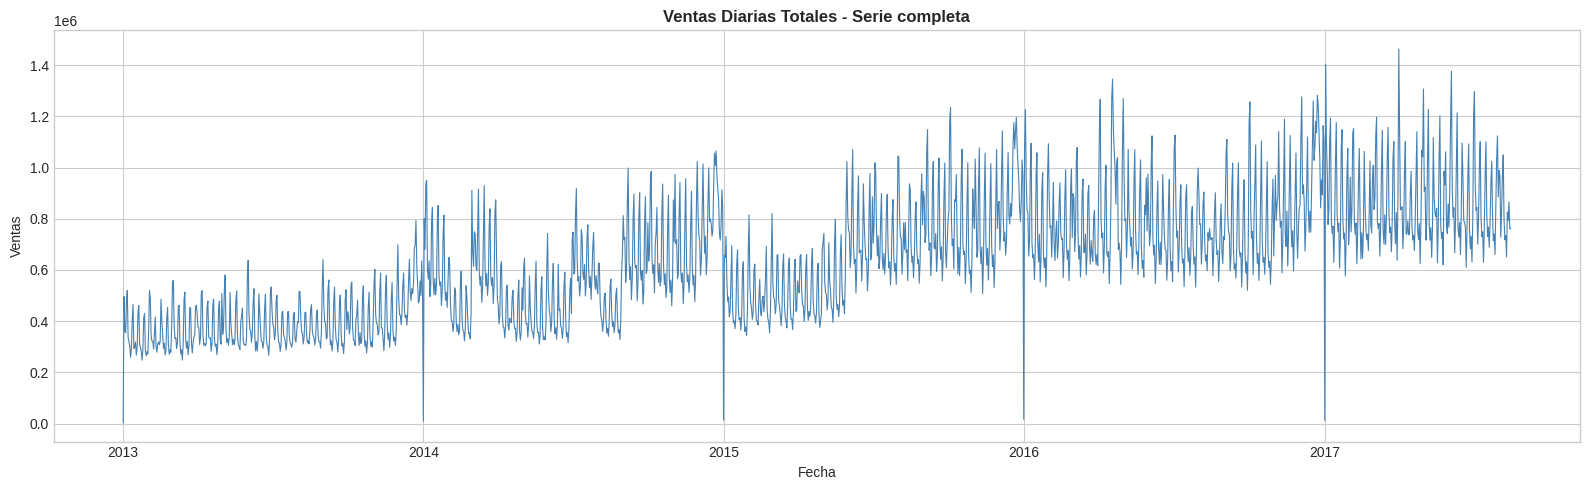

In [66]:
daily_sales = (
    train_full.groupby('date')['sales']
    .sum()
    .reset_index()
    .rename(columns={'sales':'Total_sales'})
)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_sales['date'], daily_sales['Total_sales'], linewidth=0.8, color='steelblue')
ax.set_title('Ventas Diarias Totales - Serie completa', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
plt.tight_layout()
plt.savefig('../notebooks/figures/05_daily_sales.png', dpi=150)
plt.show()

In [67]:
daily_sales.head()

,date,Total_sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


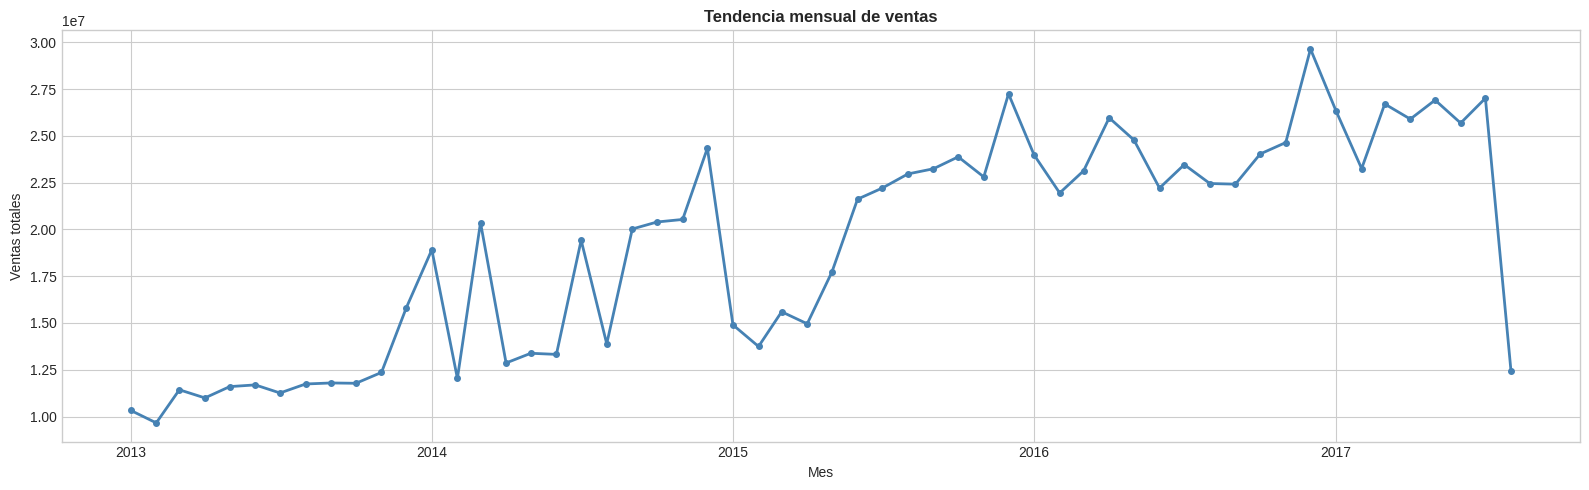

In [68]:
monthly_sales = (
    train_full.groupby(train_full['date'].dt.to_period('M'))['sales']
    .sum()
    .reset_index()
)
monthly_sales['date'] = monthly_sales['date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly_sales['date'], monthly_sales['sales'],
        marker='o', linewidth=2, markersize=4, color='steelblue')
ax.set_title('Tendencia mensual de ventas', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Ventas totales')
plt.tight_layout()
plt.savefig('../notebooks/figures/06_monthly_trend.png', dpi=150)
plt.show()

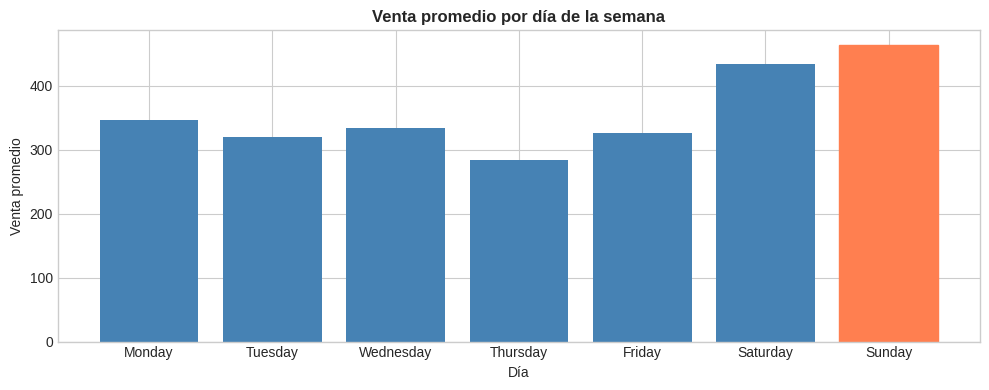

day_of_week      sales
     Monday 346.544732
    Tuesday 319.823843
  Wednesday 332.909401
   Thursday 283.540517
     Friday 325.238138
   Saturday 433.336472
     Sunday 463.085366


In [69]:
train_full['day_of_week'] = train_full['date'].dt.day_name()

dow_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

dow_sales = (
    train_full.groupby('day_of_week')['sales']
    .mean()
    .reindex(dow_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(dow_sales['day_of_week'], dow_sales['sales'],
              color='steelblue')
ax.set_title('Venta promedio por día de la semana', fontweight='bold')
ax.set_xlabel('Día')
ax.set_ylabel('Venta promedio')

# Resalta el máximo
max_idx = dow_sales['sales'].idxmax()
bars[max_idx].set_color('coral')

plt.tight_layout()
plt.savefig('../notebooks/figures/07_day_of_week.png', dpi=150)
plt.show()

print(dow_sales.to_string(index=False))

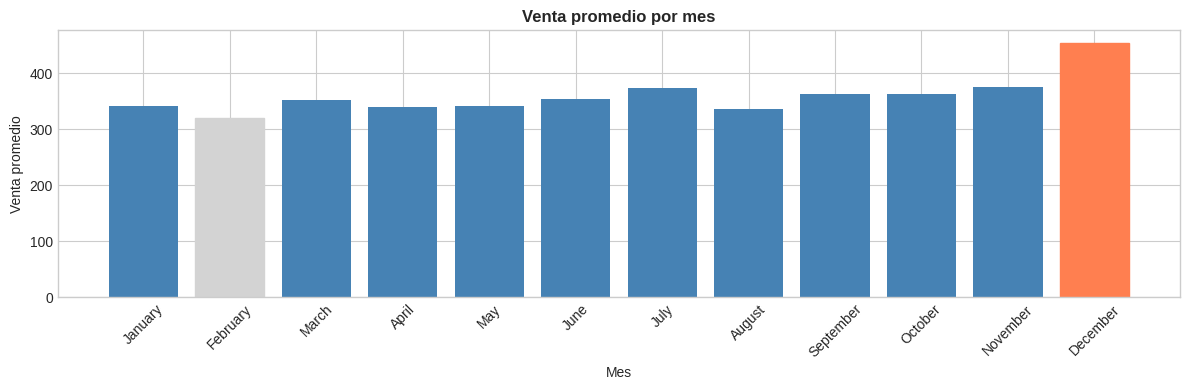

month_name      sales
   January 341.921554
  February 320.928869
     March 352.009294
     April 339.199841
       May 341.765820
      June 353.597842
      July 374.219111
    August 336.992535
 September 362.297418
   October 362.407132
  November 375.681762
  December 453.740370


In [70]:
train_full['month'] = train_full['date'].dt.month
train_full['month_name'] = train_full['date'].dt.month_name()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

month_sales = (
    train_full.groupby('month_name')['sales']
    .mean()
    .reindex(month_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(month_sales['month_name'], month_sales['sales'],
              color='steelblue')
ax.set_title('Venta promedio por mes', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Venta promedio')
plt.xticks(rotation=45)

# Resalta máximo y mínimo
max_idx = month_sales['sales'].idxmax()
min_idx = month_sales['sales'].idxmin()
bars[max_idx].set_color('coral')
bars[min_idx].set_color('lightgray')

plt.tight_layout()
plt.savefig('../notebooks/figures/08_monthly_seasonality.png', dpi=150)
plt.show()

print(month_sales.to_string(index=False))

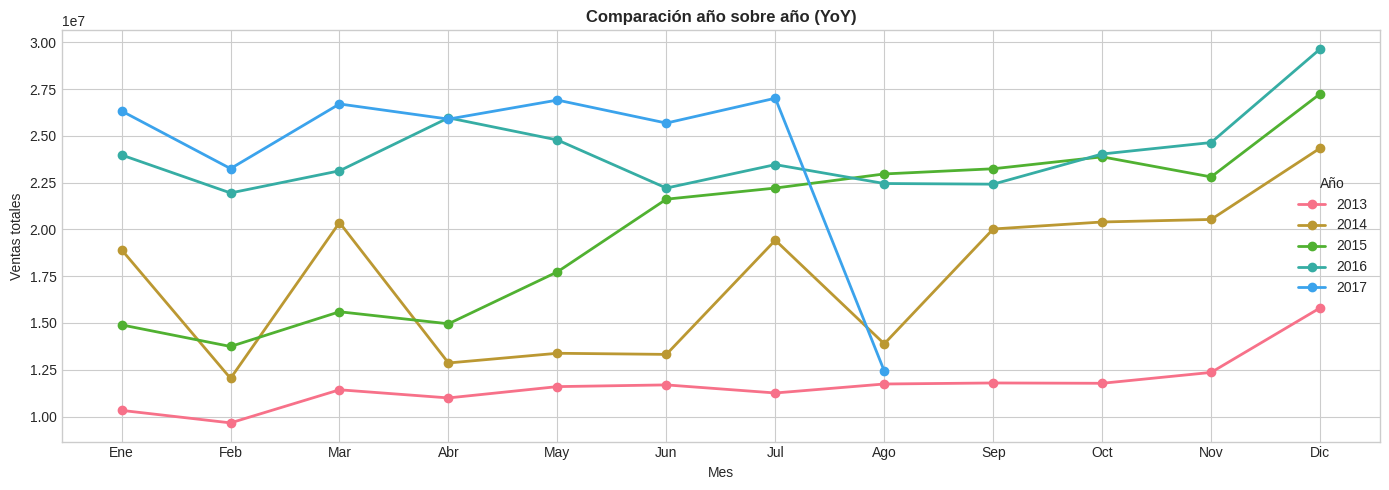

In [71]:
train_full['year'] = train_full['date'].dt.year

yoy_sales = (
    train_full.groupby(['year', 'month'])['sales']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for year in yoy_sales['year'].unique():
    data = yoy_sales[yoy_sales['year'] == year]
    ax.plot(data['month'], data['sales'],
            marker='o', label=str(year), linewidth=2)

ax.set_title('Comparación año sobre año (YoY)', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Ventas totales')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                    'Jul','Ago','Sep','Oct','Nov','Dic'])
ax.legend(title='Año')
plt.tight_layout()
plt.savefig('../notebooks/figures/09_yoy.png', dpi=150)
plt.show()

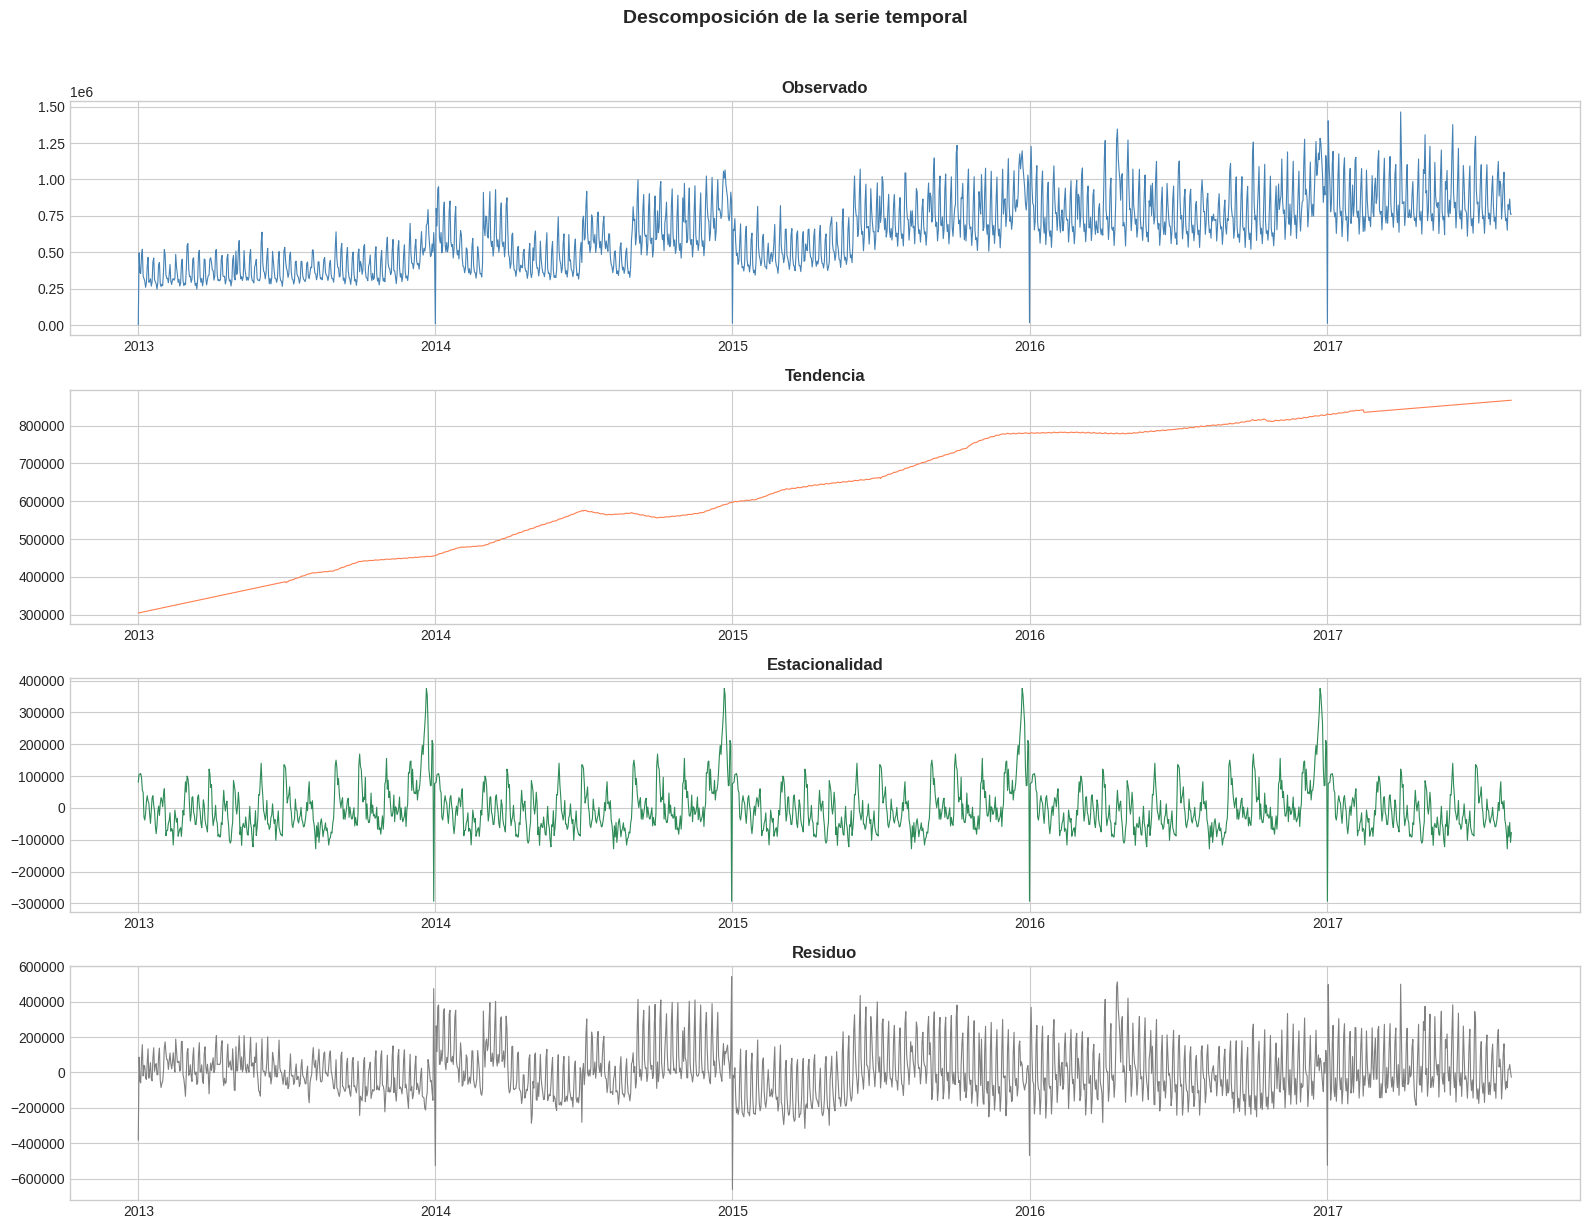

In [72]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Usamos ventas diarias agregadas para la descomposición
decomp = seasonal_decompose(
    daily_sales.set_index('date')['Total_sales'],
    model='additive',
    period=365,        # estacionalidad anual
    extrapolate_trend='freq'
)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
components = {
    'Observado':      decomp.observed,
    'Tendencia':      decomp.trend,
    'Estacionalidad': decomp.seasonal,
    'Residuo':        decomp.resid
}

colors = ['steelblue', 'coral', 'seagreen', 'gray']
for ax, (title, data), color in zip(axes, components.items(), colors):
    ax.plot(data, linewidth=0.8, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Descomposición de la serie temporal',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/figures/10_decomposition.png', dpi=150)
plt.show()

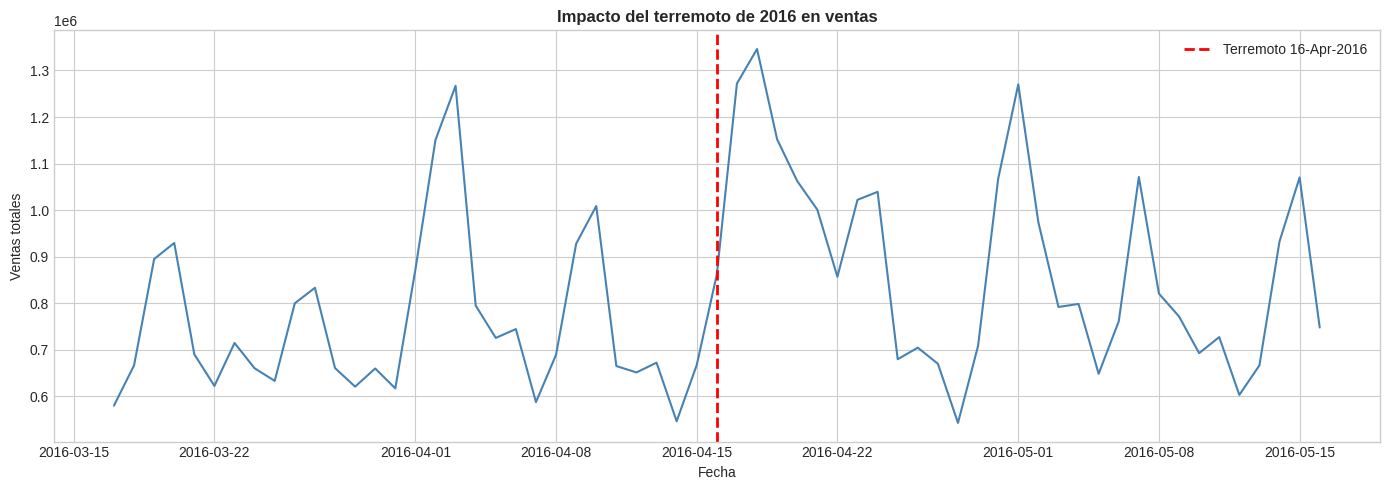

In [73]:
# Ecuador tuvo un terremoto el 16 de abril de 2016
# Es un evento atípico que debemos identificar

earthquake_date = pd.Timestamp('2016-04-16')
window = 30  # días antes y después

mask = (
    (daily_sales['date'] >= earthquake_date - pd.Timedelta(days=window)) &
    (daily_sales['date'] <= earthquake_date + pd.Timedelta(days=window))
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_sales[mask]['date'],
        daily_sales[mask]['Total_sales'],
        linewidth=1.5, color='steelblue')
ax.axvline(x=earthquake_date, color='red',
           linestyle='--', linewidth=2, label='Terremoto 16-Apr-2016')
ax.set_title('Impacto del terremoto de 2016 en ventas', fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas totales')
ax.legend()
plt.tight_layout()
plt.savefig('../notebooks/figures/11_earthquake.png', dpi=150)
plt.show()

In [74]:
# Distribución de tipos de festivos
print("Tipos de festivos:")
print(holidays['type'].value_counts())
print(f"\n Tipos de locale:")
print(holidays['locale'].value_counts())
print(f"\n Festivos transferidos:")
print(holidays['transferred'].value_counts())
print(f"\n Total fechas únicas con festivo:")
print(holidays['date'].nunique())
print(f"\n Top 10 festividades más frecuentes:")
print(holidays['description'].value_counts().head(10))

Tipos de festivos:
type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

 Tipos de locale:
locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

 Festivos transferidos:
transferred
False    338
True      12
Name: count, dtype: int64

 Total fechas únicas con festivo:
312

 Top 10 festividades más frecuentes:
description
Carnaval                         10
Fundacion de Ibarra               7
Fundacion de Cuenca               7
Cantonizacion de Libertad         6
Cantonizacion de Riobamba         6
Cantonizacion del Puyo            6
Fundacion de Manta                6
Cantonizacion de Guaranda         6
Provincializacion de Imbabura     6
Fundacion de Machala              6
Name: count, dtype: int64


📊 Ventas promedio: día normal vs festivo
               mean  median      std
es_festivo                          
Día normal   352.39    11.0  1077.94
Día festivo  412.76    12.0  1321.67


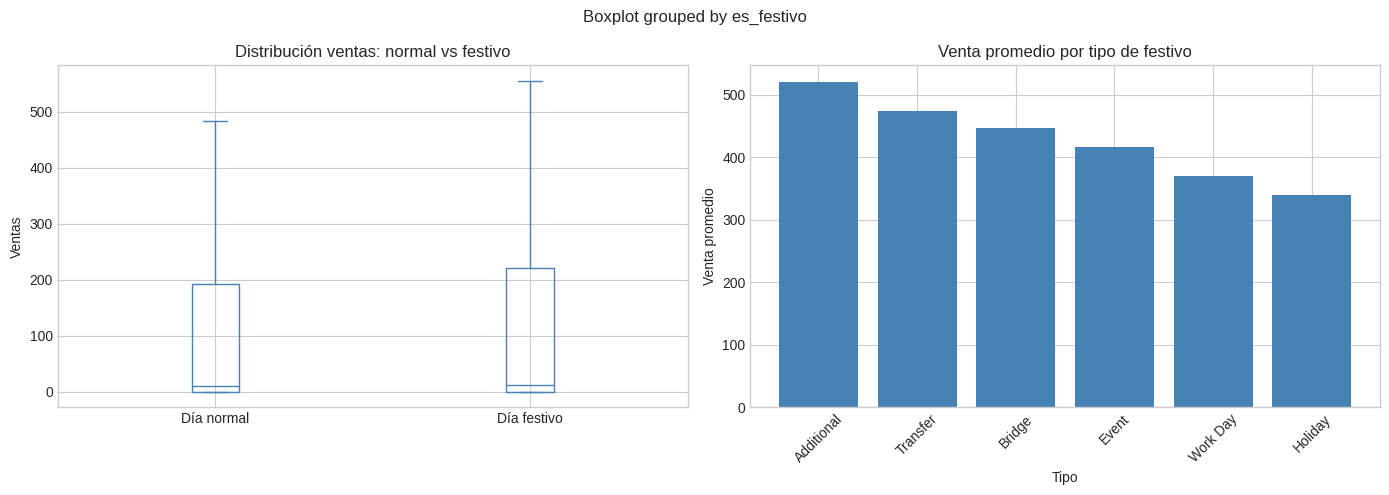

In [75]:
# Creamos flag de festivo en train_full
train_full['es_festivo'] = train_full['holiday_type'].notna().astype(int)

# Comparación ventas día normal vs festivo
festivo_comparison = (
    train_full.groupby('es_festivo')['sales']
    .agg(['mean', 'median', 'std'])
    .round(2)
    .rename(index={0: 'Día normal', 1: 'Día festivo'})
)

print("📊 Ventas promedio: día normal vs festivo")
print(festivo_comparison)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
train_full.boxplot(column='sales', by='es_festivo',
                   ax=axes[0], showfliers=False, color='steelblue')
axes[0].set_title('Distribución ventas: normal vs festivo')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['Día normal', 'Día festivo'])
axes[0].set_ylabel('Ventas')

# Promedio por tipo de festivo
festivo_type = (
    train_full.groupby('holiday_type')['sales']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
axes[1].bar(festivo_type['holiday_type'],
            festivo_type['sales'],
            color='steelblue')
axes[1].set_title('Venta promedio por tipo de festivo')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Venta promedio')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../notebooks/figures/12_holiday_impact.png', dpi=150)
plt.show()

Impacto por locale del festivo:
            mean  median   count
locale                          
National  412.58    12.0  254826


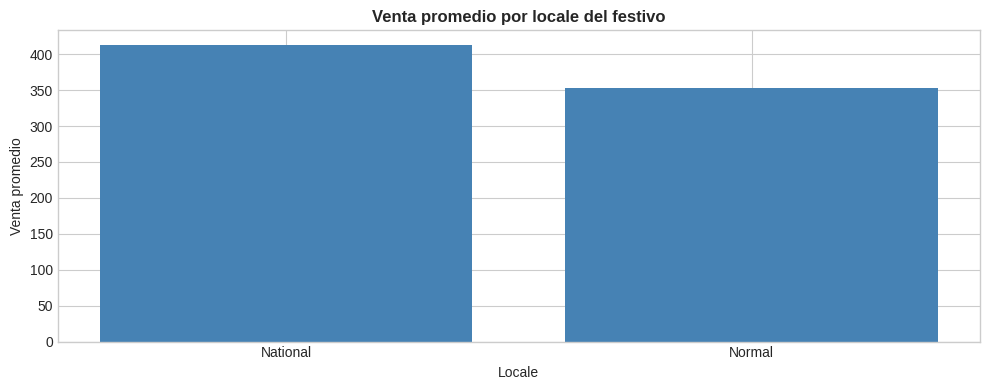

In [76]:
# ¿Impacta igual un festivo nacional que uno local?
locale_impact = (
    train_full[train_full['es_festivo'] == 1]
    .groupby('locale')['sales']
    .agg(['mean', 'median', 'count'])
    .round(2)
    .sort_values('mean', ascending=False)
)

print("Impacto por locale del festivo:")
print(locale_impact)

# Comparación visual
fig, ax = plt.subplots(figsize=(10, 4))
locale_sales = (
    train_full.groupby(
        train_full['locale'].fillna('Normal')
    )['sales'].mean()
    .sort_values(ascending=False)
)
ax.bar(locale_sales.index, locale_sales.values, color='steelblue')
ax.set_title('Venta promedio por locale del festivo', fontweight='bold')
ax.set_xlabel('Locale')
ax.set_ylabel('Venta promedio')
plt.tight_layout()
plt.savefig('../notebooks/figures/13_locale_impact.png', dpi=150)
plt.show()


In [89]:
train_full['locale'].unique()

array(['National', nan], dtype=object)

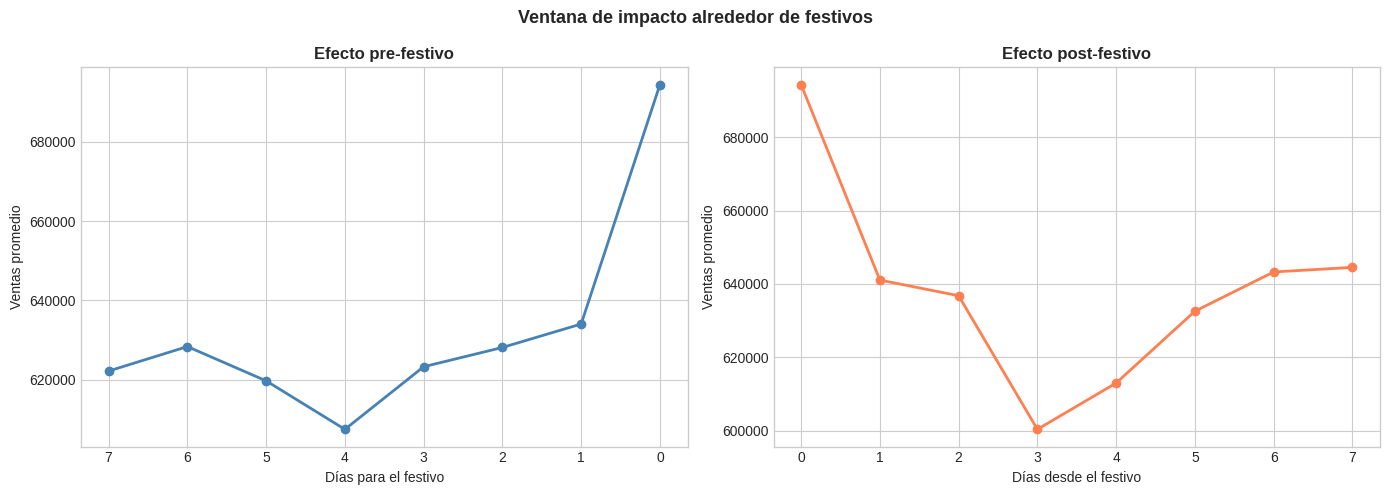

In [77]:
# Los días ANTES y DESPUÉS de un festivo
# suelen tener comportamiento distinto

# Creamos columnas de distancia al festivo
festivos_dates = train_full[
    train_full['es_festivo'] == 1
]['date'].unique()

def days_to_nearest_holiday(date, holidays):
    future = [(h - date).days for h in holidays if h >= date]
    past   = [(date - h).days for h in holidays if h <= date]
    next_h = min(future) if future else 999
    last_h = min(past)   if past   else 999
    return next_h, last_h

# Aplicar sobre ventas diarias agregadas
daily_sales['days_to_next'] = daily_sales['date'].apply(
    lambda x: days_to_nearest_holiday(x, festivos_dates)[0]
)
daily_sales['days_from_last'] = daily_sales['date'].apply(
    lambda x: days_to_nearest_holiday(x, festivos_dates)[1]
)

# Efecto pre-festivo (ventana de 7 días)
pre_holiday = (
    daily_sales[daily_sales['days_to_next'] <= 7]
    .groupby('days_to_next')['Total_sales']
    .mean()
)

# Efecto post-festivo (ventana de 7 días)
post_holiday = (
    daily_sales[daily_sales['days_from_last'] <= 7]
    .groupby('days_from_last')['Total_sales']
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pre_holiday.index, pre_holiday.values,
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Efecto pre-festivo', fontweight='bold')
axes[0].set_xlabel('Días para el festivo')
axes[0].set_ylabel('Ventas promedio')
axes[0].invert_xaxis()

axes[1].plot(post_holiday.index, post_holiday.values,
             marker='o', color='coral', linewidth=2)
axes[1].set_title('Efecto post-festivo', fontweight='bold')
axes[1].set_xlabel('Días desde el festivo')
axes[1].set_ylabel('Ventas promedio')

plt.suptitle('Ventana de impacto alrededor de festivos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/figures/14_pre_post_holiday.png', dpi=150)
plt.show()

In [78]:
# Distribución de onpromotion
print("🏷️ Estadísticas de onpromotion:")
print(train_full['onpromotion'].describe().round(2))
print(f"\nDías sin promoción: "
      f"{(train_full['onpromotion'] == 0).mean()*100:.1f}%")
print(f"Días con promoción: "
      f"{(train_full['onpromotion'] > 0).mean()*100:.1f}%")

# Impacto de promociones en ventas
train_full['tiene_promo'] = (
    train_full['onpromotion'] > 0
).astype(int)

promo_impact = (
    train_full.groupby('tiene_promo')['sales']
    .agg(['mean', 'median'])
    .round(2)
    .rename(index={0: 'Sin promo', 1: 'Con promo'})
)
print(f"\n📊 Impacto de promociones en ventas:")
print(promo_impact)

🏷️ Estadísticas de onpromotion:
count    3000888.00
mean           2.60
std           12.22
min            0.00
25%            0.00
50%            0.00
75%            0.00
max          741.00
Name: onpromotion, dtype: float64

Días sin promoción: 79.6%
Días con promoción: 20.4%

📊 Impacto de promociones en ventas:
                mean  median
tiene_promo                 
Sin promo     158.25     3.0
Con promo    1137.69   373.0


🏷️ Lift de promoción por familia:
                    family  pct_promo  lift_promo
SCHOOL AND OFFICE SUPPLIES      0.045      43.570
                 BABY CARE      0.001      15.146
              PET SUPPLIES      0.034       4.515
       HOME AND KITCHEN II      0.209       4.006
                   PRODUCE      0.339       3.078
           HOME APPLIANCES      0.001       3.057
           LAWN AND GARDEN      0.047       3.046
                 HOME CARE      0.358       3.035
   PLAYERS AND ELECTRONICS      0.009       2.855
                    BEAUTY      0.122       2.693
                LADIESWEAR      0.005       2.690
               CELEBRATION      0.035       2.513
                 BEVERAGES      0.569       2.488
        HOME AND KITCHEN I      0.161       2.344
                AUTOMOTIVE      0.034       2.262
              FROZEN FOODS      0.394       2.150
                  HARDWARE      0.001       2.087
                     DAIRY      0.506       1.945
                

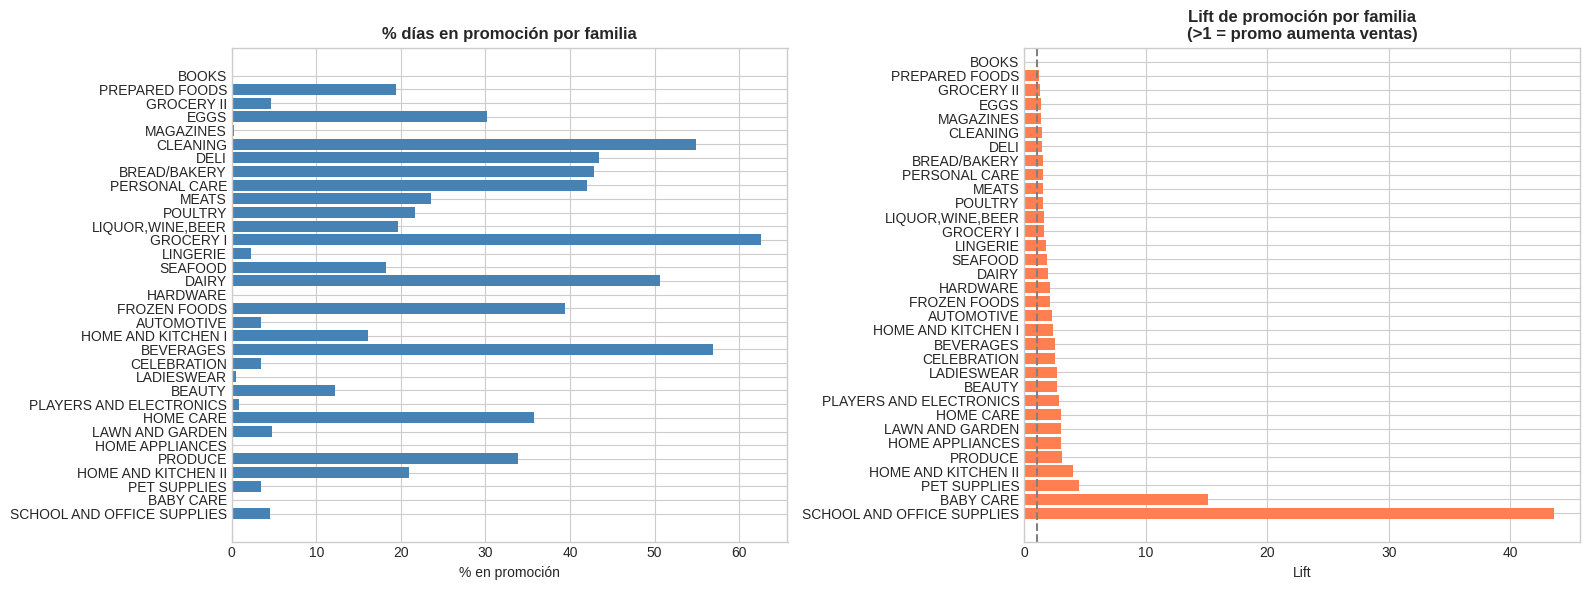

In [79]:
promo_by_family = (
    train_full.groupby('family')
    .agg(
        pct_promo=('tiene_promo', 'mean'),
        lift_promo=('sales', lambda x:
            x[train_full.loc[x.index, 'tiene_promo'] == 1].mean() /
            x[train_full.loc[x.index, 'tiene_promo'] == 0].mean()
        )
    )
    .round(3)
    .sort_values('lift_promo', ascending=False)
    .reset_index()
)

print("🏷️ Lift de promoción por familia:")
print(promo_by_family.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(promo_by_family['family'],
             promo_by_family['pct_promo'] * 100,
             color='steelblue')
axes[0].set_title('% días en promoción por familia',
                  fontweight='bold')
axes[0].set_xlabel('% en promoción')

axes[1].barh(promo_by_family['family'],
             promo_by_family['lift_promo'],
             color='coral')
axes[1].axvline(x=1, color='gray', linestyle='--')
axes[1].set_title('Lift de promoción por familia\n(>1 = promo aumenta ventas)',
                  fontweight='bold')
axes[1].set_xlabel('Lift')

plt.tight_layout()
plt.savefig('../notebooks/figures/15_promo_by_family.png', dpi=150)
plt.show()

In [80]:
# ¿Las promociones en festivos tienen mayor impacto?
combo_analysis = (
    train_full.groupby(['es_festivo', 'tiene_promo'])['sales']
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={
        'es_festivo': 'Festivo',
        'tiene_promo': 'Promocion',
        'sales': 'Venta promedio'
    })
)
combo_analysis['Festivo']   = combo_analysis['Festivo'].map({0:'No',1:'Sí'})
combo_analysis['Promocion'] = combo_analysis['Promocion'].map({0:'No',1:'Sí'})

print(" Combinación festivo + promoción:")
print(combo_analysis.to_string(index=False))

 Combinación festivo + promoción:
Festivo Promocion  Venta promedio
     No        No          159.13
     No        Sí         1124.53
     Sí        No          148.77
     Sí        Sí         1249.93


In [81]:
# Paso 1 — Verificar si hay duplicados post-merge
print("🔍 Duplicados en train_full:")
duplicados = train_full.duplicated(
    subset=['date', 'store_nbr', 'family']
).sum()
print(f"  Filas duplicadas: {duplicados:,}")
print(f"  Shape actual:     {train_full.shape}")
print(f"  Shape esperado:   ~3,054,348 filas")

# Paso 2 — Verificar si holidays tiene fechas duplicadas
print(f"\n🔍 Fechas duplicadas en holidays:")
holiday_dupes = holidays['date'].value_counts()
print(holiday_dupes[holiday_dupes > 1].head(10))
print(f"  Fechas con más de 1 registro: "
      f"{(holiday_dupes > 1).sum()}")

# Paso 3 — Ver un ejemplo concreto
print(f"\n🔍 Ejemplo — festivos en una misma fecha:")
sample_date = holidays[
    holidays['date'].isin(
        holiday_dupes[holiday_dupes > 1].index
    )
]['date'].iloc[0]
print(holidays[holidays['date'] == sample_date])

🔍 Duplicados en train_full:
  Filas duplicadas: 0
  Shape actual:     (3000888, 22)
  Shape esperado:   ~3,054,348 filas

🔍 Fechas duplicadas en holidays:
date
2014-06-25    4
2016-06-25    3
2012-06-25    3
2015-06-25    3
2017-06-25    3
2013-06-25    3
2015-12-22    2
2012-12-22    2
2012-12-24    2
2012-12-31    2
Name: count, dtype: int64
  Fechas con más de 1 registro: 31

🔍 Ejemplo — festivos en una misma fecha:
        date     type    locale locale_name                    description  \
7 2012-06-25  Holiday  Regional    Imbabura  Provincializacion de Imbabura   
8 2012-06-25  Holiday     Local   Latacunga     Cantonizacion de Latacunga   
9 2012-06-25  Holiday     Local     Machala           Fundacion de Machala   

   transferred  
7        False  
8        False  
9        False  


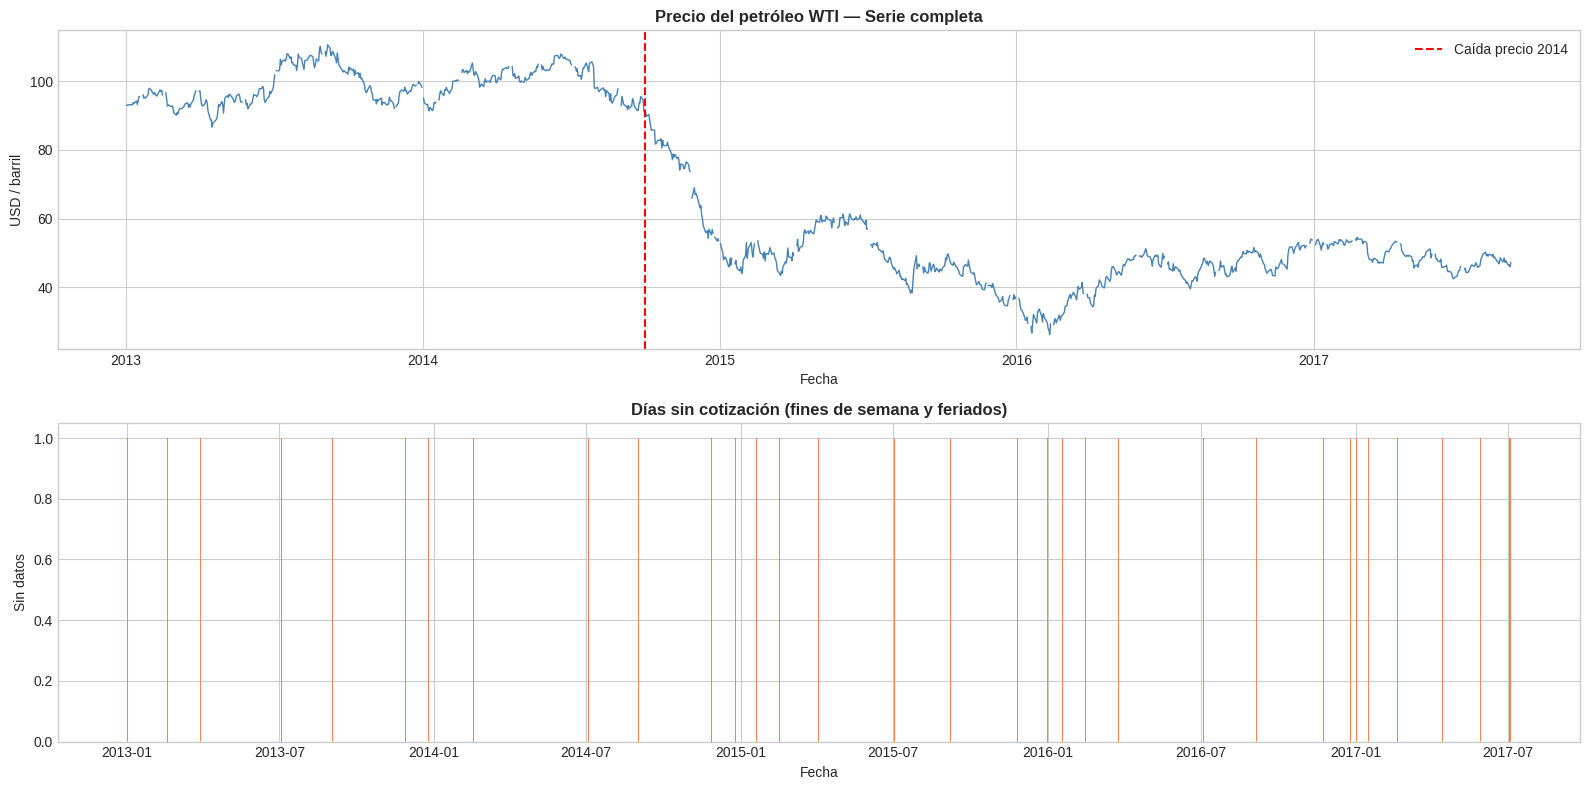

📊 Estadísticas del precio del petróleo:
count    1175.00
mean       67.71
std        25.63
min        26.19
25%        46.40
50%        53.19
75%        95.66
max       110.62
Name: dcoilwtico, dtype: float64

Nulos: 43 (3.5%)


In [82]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Serie completa del precio
axes[0].plot(oil['date'], oil['dcoilwtico'],
             linewidth=1, color='steelblue')
axes[0].set_title('Precio del petróleo WTI — Serie completa',
                  fontweight='bold')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('USD / barril')
axes[0].axvline(pd.Timestamp('2014-10-01'),
                color='red', linestyle='--',
                label='Caída precio 2014')
axes[0].legend()

# Nulos en oil
oil_null = oil.set_index('date')['dcoilwtico'].isnull()
axes[1].bar(oil_null[oil_null].index,
            [1] * oil_null.sum(),
            color='coral', width=1)
axes[1].set_title('Días sin cotización (fines de semana y feriados)',
                  fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Sin datos')

plt.tight_layout()
plt.savefig('../notebooks/figures/16_oil_series.png', dpi=150)
plt.show()

print(f"📊 Estadísticas del precio del petróleo:")
print(oil['dcoilwtico'].describe().round(2))
print(f"\nNulos: {oil['dcoilwtico'].isnull().sum()} "
      f"({oil['dcoilwtico'].isnull().mean()*100:.1f}%)")

📊 Correlación Pearson Oil vs Ventas: -0.705


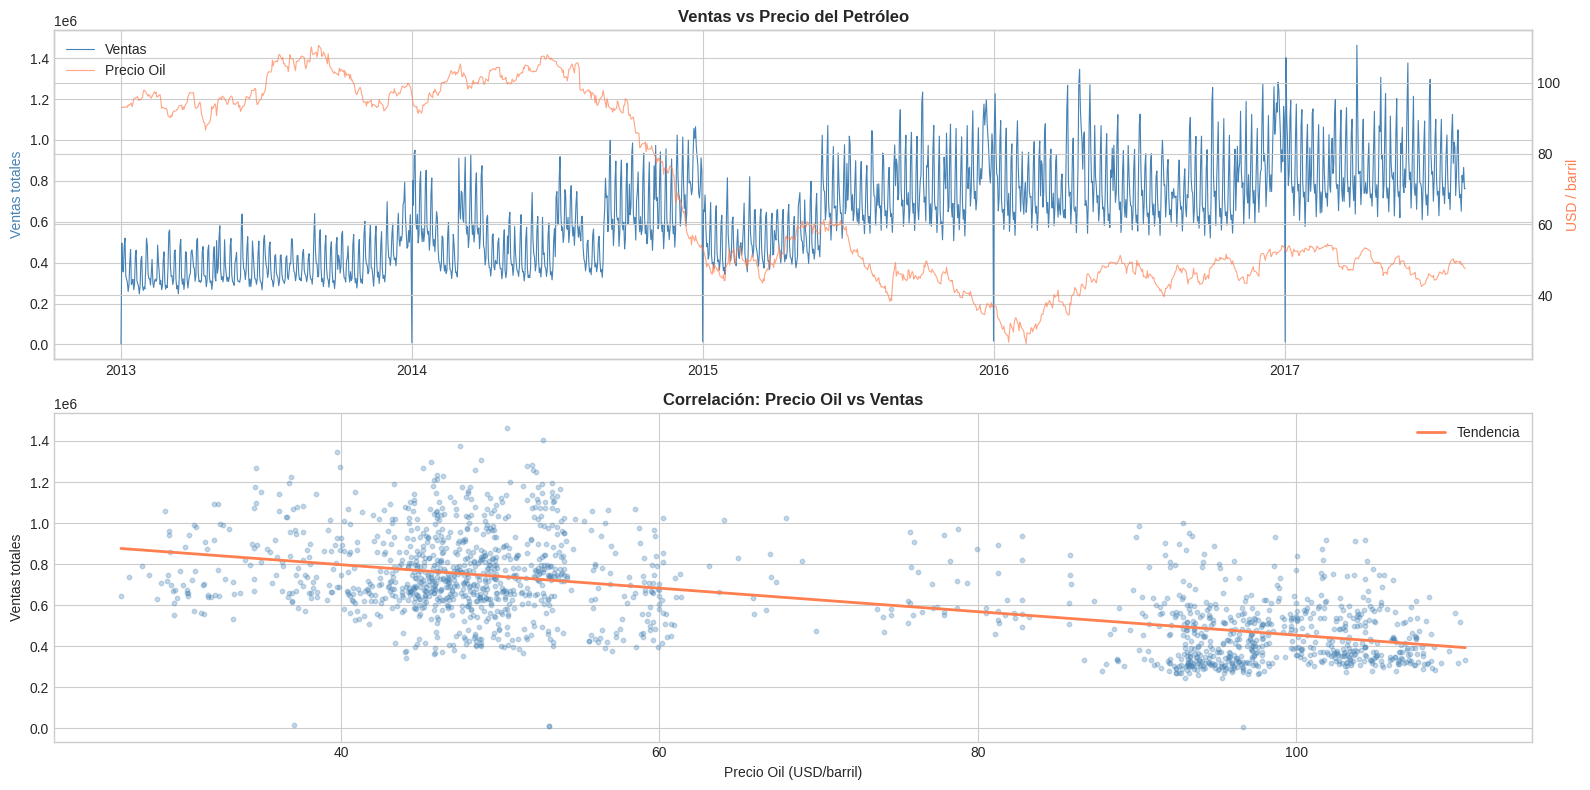

In [83]:
# Merge oil con ventas diarias
daily_oil = (
    daily_sales
    .merge(oil, on='date', how='left')
)

# Interpolamos oil para esta visualización
daily_oil['oil_interpolated'] = (
    daily_oil['dcoilwtico']
    .interpolate(method='linear')
)

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Oil vs ventas en el tiempo
ax1 = axes[0]
ax2 = ax1.twinx()  # eje secundario

ax1.plot(daily_oil['date'], daily_oil['Total_sales'],
         color='steelblue', linewidth=0.8, label='Ventas')
ax2.plot(daily_oil['date'], daily_oil['oil_interpolated'],
         color='coral', linewidth=0.8, label='Precio Oil',
         alpha=0.7)

ax1.set_title('Ventas vs Precio del Petróleo', fontweight='bold')
ax1.set_ylabel('Ventas totales', color='steelblue')
ax2.set_ylabel('USD / barril', color='coral')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

# Scatter correlación
axes[1].scatter(daily_oil['oil_interpolated'],
                daily_oil['Total_sales'],
                alpha=0.3, color='steelblue', s=10)
axes[1].set_title('Correlación: Precio Oil vs Ventas',
                  fontweight='bold')
axes[1].set_xlabel('Precio Oil (USD/barril)')
axes[1].set_ylabel('Ventas totales')

# Línea de tendencia
mask = daily_oil['oil_interpolated'].notna()
z = np.polyfit(daily_oil[mask]['oil_interpolated'],
               daily_oil[mask]['Total_sales'], 1)
p = np.poly1d(z)
x_line = np.linspace(daily_oil['oil_interpolated'].min(),
                     daily_oil['oil_interpolated'].max(), 100)
axes[1].plot(x_line, p(x_line), color='coral',
             linewidth=2, label='Tendencia')
axes[1].legend()

corr = daily_oil[mask]['dcoilwtico'].corr(
    daily_oil[mask]['Total_sales']
)
print(f"📊 Correlación Pearson Oil vs Ventas: {corr:.3f}")

plt.tight_layout()
plt.savefig('../notebooks/figures/17_oil_vs_sales.png', dpi=150)
plt.show()

📊 Estadísticas de transacciones:
count    83488.00
mean      1694.60
std        963.29
min          5.00
25%       1046.00
50%       1393.00
75%       2079.00
max       8359.00
Name: transactions, dtype: float64


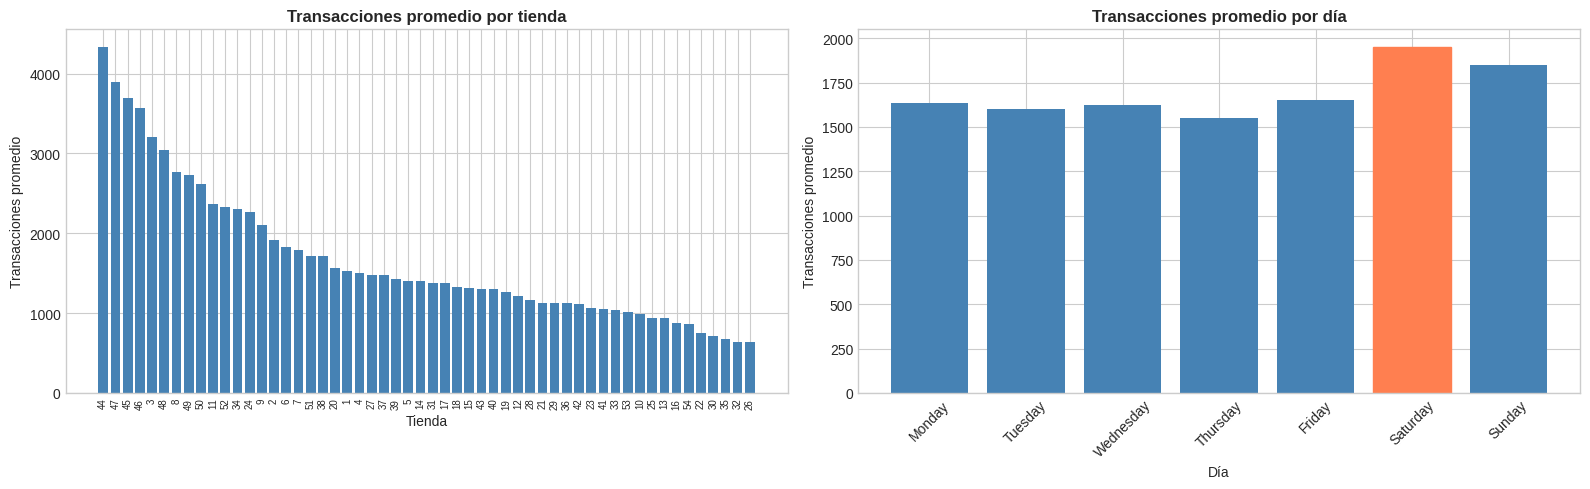

In [84]:
print("📊 Estadísticas de transacciones:")
print(transactions['transactions'].describe().round(2))

# Transacciones por tienda
trans_by_store = (
    transactions.groupby('store_nbr')['transactions']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(trans_by_store['store_nbr'].astype(str),
            trans_by_store['transactions'],
            color='steelblue')
axes[0].set_title('Transacciones promedio por tienda',
                  fontweight='bold')
axes[0].set_xlabel('Tienda')
axes[0].set_ylabel('Transacciones promedio')
plt.sca(axes[0])
plt.xticks(rotation=90, fontsize=7)

# Transacciones por día de semana
transactions['day_of_week'] = pd.to_datetime(
    transactions['date']
).dt.day_name()

dow_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']

trans_dow = (
    transactions.groupby('day_of_week')['transactions']
    .mean()
    .reindex(dow_order)
    .reset_index()
)

bars = axes[1].bar(trans_dow['day_of_week'],
                   trans_dow['transactions'],
                   color='steelblue')
axes[1].set_title('Transacciones promedio por día',
                  fontweight='bold')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Transacciones promedio')
plt.sca(axes[1])
plt.xticks(rotation=45)

max_idx = trans_dow['transactions'].idxmax()
bars[max_idx].set_color('coral')

plt.tight_layout()
plt.savefig('../notebooks/figures/18_transactions.png', dpi=150)
plt.show()

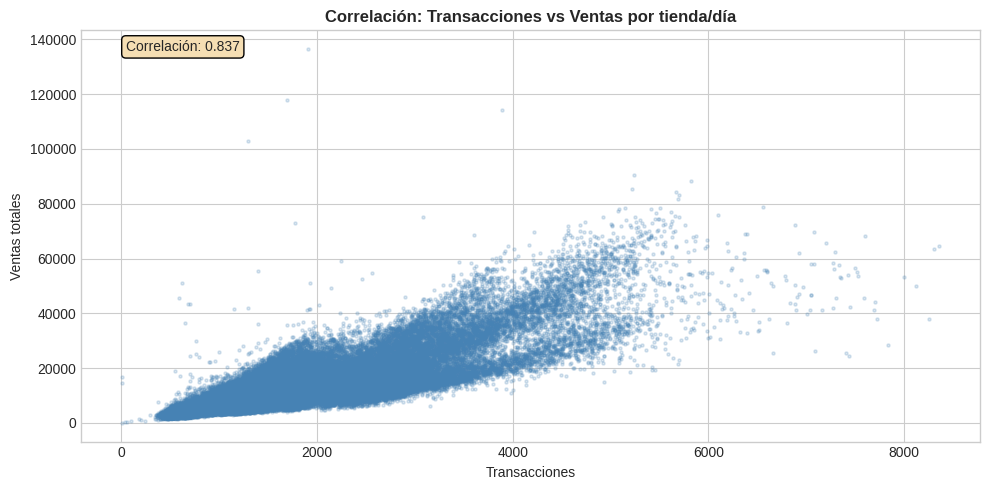

📊 Correlación Pearson Transacciones vs Ventas: 0.837


In [85]:
# Transacciones vs ventas por tienda y fecha
trans_sales = (
    train_full.groupby(['date', 'store_nbr'])
    .agg(
        total_sales=('sales', 'sum'),
        transactions=('transactions', 'first')
    )
    .reset_index()
    .dropna()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(trans_sales['transactions'],
           trans_sales['total_sales'],
           alpha=0.2, color='steelblue', s=5)
ax.set_title('Correlación: Transacciones vs Ventas por tienda/día',
             fontweight='bold')
ax.set_xlabel('Transacciones')
ax.set_ylabel('Ventas totales')

corr = trans_sales['transactions'].corr(trans_sales['total_sales'])
ax.text(0.05, 0.95, f'Correlación: {corr:.3f}',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='wheat'))

plt.tight_layout()
plt.savefig('../notebooks/figures/19_transactions_vs_sales.png', dpi=150)
plt.show()

print(f"📊 Correlación Pearson Transacciones vs Ventas: {corr:.3f}")

In [86]:
# ¿Cuáles festivos específicamente
# tienen ventas menores al promedio normal?
baseline = train_full[
    (train_full['es_festivo'] == 0) &
    (train_full['tiene_promo'] == 0)
]['sales'].mean()

festivo_detail = (
    train_full[
        (train_full['es_festivo'] == 1) &
        (train_full['tiene_promo'] == 0)
    ]
    .groupby('holiday_description')['sales']
    .agg(['mean', 'count'])
    .round(2)
    .sort_values('mean', ascending=True)
    .reset_index()
)

festivo_detail['vs_baseline'] = (
    (festivo_detail['mean'] - baseline) / baseline * 100
).round(1)

print(f"📊 Baseline día normal sin promo: {baseline:.2f}")
print(f"\n🔍 Festivos ordenados por impacto en ventas:")
print(festivo_detail.to_string(index=False))

# ¿Cuántas ventas en cero hay en días festivos?
zeros_festivo = (
    train_full[train_full['es_festivo'] == 1]['sales'] == 0
).mean() * 100

zeros_normal = (
    train_full[train_full['es_festivo'] == 0]['sales'] == 0
).mean() * 100

print(f"\n📊 % ventas en cero:")
print(f"  Días festivos: {zeros_festivo:.1f}%")
print(f"  Días normales: {zeros_normal:.1f}%")


📊 Baseline día normal sin promo: 159.13

🔍 Festivos ordenados por impacto en ventas:
                            holiday_description   mean  count  vs_baseline
                             Primer dia del ano   2.45   8880        -98.5
                         Cantonizacion del Puyo   3.14    138        -98.0
                             Fundacion de Manta  11.55    301        -92.7
                  Traslado Batalla de Pichincha  17.23   1775        -89.2
         Traslado Primer Grito de Independencia  28.19   1872        -82.3
                            Terremoto Manabi+11  29.50   1105        -81.5
                            Terremoto Manabi+18  30.76   1049        -80.7
                Recupero Puente Dia de Difuntos  43.09    913        -72.9
                     Cantonizacion de El Carmen  45.12    126        -71.6
                             Terremoto Manabi+4  47.02   1139        -70.5
                             Terremoto Manabi+6  48.05   1099        -69.8
               